In [0]:
visits = spark.table("workspace.default.air_visits").toPandas()
stores = spark.table("workspace.default.air_stores").toPandas()
dates = spark.table("workspace.default.date_info").toPandas()

In [0]:
print("visits shape:", visits.shape)
print("stores shape:", stores.shape)
print("dates shape:", dates.shape)

visits shape: (252108, 3)
stores shape: (829, 5)
dates shape: (517, 3)


In [0]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252108 entries, 0 to 252107
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   air_store_id  252108 non-null  object
 1   visit_date    252108 non-null  object
 2   visitors      252108 non-null  int32 
dtypes: int32(1), object(2)
memory usage: 4.8+ MB


In [0]:
import pandas as pd
visits["visit_date"] = pd.to_datetime(visits["visit_date"])

In [0]:
visits.head()

,air_store_id,visit_date,visitors
0,air_ba937bf13d40fb24,2016-01-13,25
1,air_ba937bf13d40fb24,2016-01-14,32
2,air_ba937bf13d40fb24,2016-01-15,29
3,air_ba937bf13d40fb24,2016-01-16,22
4,air_ba937bf13d40fb24,2016-01-18,6


In [0]:
print("From date: ", visits["visit_date"].min())
print("To date: ", visits["visit_date"].max())
print("Num of days: ", visits["visit_date"].max() - visits["visit_date"].min())

From date:  2016-01-01 00:00:00
To date:  2017-04-22 00:00:00
Num of days:  477 days 00:00:00


In [0]:
print("Num of unique stores: ", visits["air_store_id"].nunique())

Num of unique stores:  829


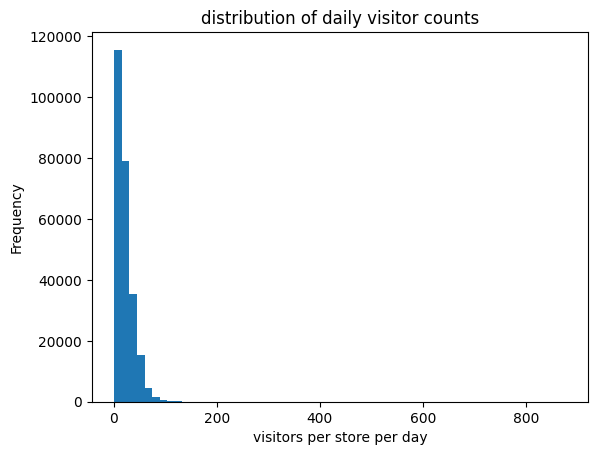

In [0]:
import matplotlib.pyplot as plt

visits["visitors"].plot(kind="hist", bins=60)
plt.xlabel("visitors per store per day")
plt.title("distribution of daily visitor counts")
plt.show()

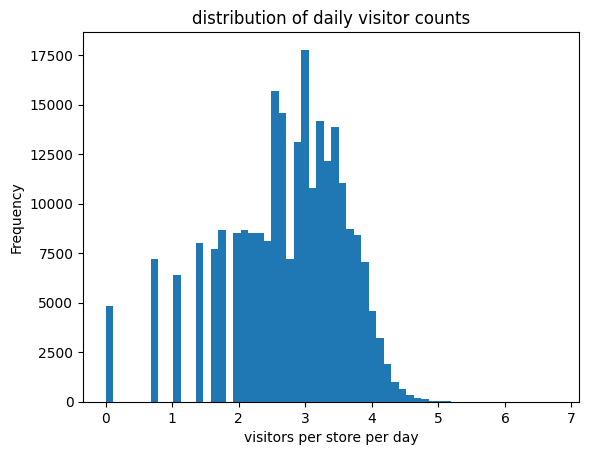

In [0]:
import numpy as np

np.log(visits["visitors"]).plot(kind="hist", bins=60)
plt.xlabel("visitors per store per day")
plt.title("distribution of daily visitor counts")
plt.show()

In [0]:
dates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   calendar_date  517 non-null    object
 1   day_of_week    517 non-null    object
 2   holiday_flg    517 non-null    int32 
dtypes: int32(1), object(2)
memory usage: 10.2+ KB


In [0]:
dates["calendar_date"] = pd.to_datetime(dates["calendar_date"])

In [0]:
dates.head()

,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1
3,2016-01-04,Monday,0
4,2016-01-05,Tuesday,0


In [0]:
visits_cal = visits.merge(dates, left_on="visit_date", right_on="calendar_date", how='left')
visits_cal.head()

,air_store_id,visit_date,visitors,calendar_date,day_of_week,holiday_flg
0,air_ba937bf13d40fb24,2016-01-13,25,2016-01-13,Wednesday,0
1,air_ba937bf13d40fb24,2016-01-14,32,2016-01-14,Thursday,0
2,air_ba937bf13d40fb24,2016-01-15,29,2016-01-15,Friday,0
3,air_ba937bf13d40fb24,2016-01-16,22,2016-01-16,Saturday,0
4,air_ba937bf13d40fb24,2016-01-18,6,2016-01-18,Monday,0


In [0]:
visits_cal.isnull().sum()

air_store_id     0
visit_date       0
visitors         0
calendar_date    0
day_of_week      0
holiday_flg      0
dtype: int64

In [0]:
dow = visits_cal.groupby("day_of_week")["visitors"].mean()
dow.sort_values(ascending=False)

day_of_week
Saturday     26.313688
Sunday       23.873362
Friday       23.072737
Wednesday    19.230121
Thursday     18.922702
Tuesday      17.672137
Monday       17.177009
Name: visitors, dtype: float64

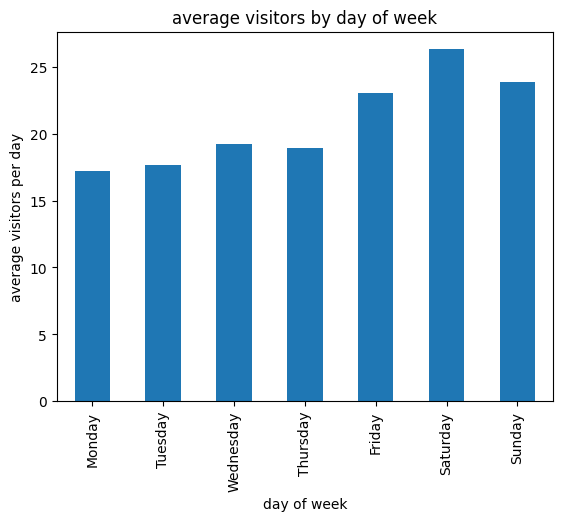

In [0]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = dow.reindex(order)

dow.plot(kind="bar")
plt.xlabel("day of week")
plt.ylabel("average visitors per day")
plt.title("average visitors by day of week")
plt.show()

In [0]:
holiday = visits_cal.groupby("holiday_flg")["visitors"].mean()
holiday

holiday_flg
0    20.828064
1    23.703327
Name: visitors, dtype: float64

In [0]:
daily_total = visits.groupby("visit_date")["visitors"].sum()
daily_total.sort_values(ascending=False)

visit_date
2016-12-17    23982
2017-03-25    22836
2016-12-10    22794
2017-03-11    22040
2016-12-03    21895
              ...  
2016-01-04     3326
2016-01-18     3274
2016-01-03     2368
2016-01-02     1764
2016-01-01     1033
Name: visitors, Length: 478, dtype: int32

In [0]:
active_stores = visits.groupby("visit_date")["air_store_id"].nunique()
active_stores.sort_values(ascending=False)

visit_date
2017-03-17    799
2017-04-14    791
2017-03-03    791
2017-03-24    789
2017-03-31    786
             ... 
2016-01-04    157
2017-01-01    147
2016-01-03     81
2016-01-02     63
2016-01-01     48
Name: air_store_id, Length: 478, dtype: int64

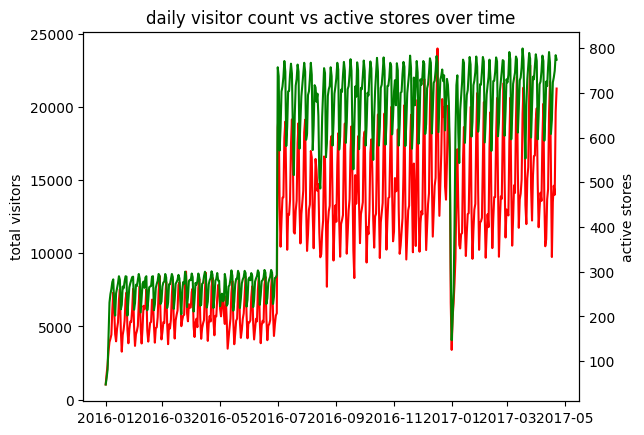

In [0]:
fig, ax1 = plt.subplots()

ax1.plot(daily_total.index, daily_total.values, color="r")
ax1.set_ylabel("total visitors")

ax2 = ax1.twinx()
ax2.plot(active_stores.index, active_stores.values, color="g")
ax2.set_ylabel("active stores")

plt.title("daily visitor count vs active stores over time")
plt.show()

In [0]:
hist_len = visits.groupby("air_store_id")["visit_date"].count()
hist_len.describe()


count    829.000000
mean     304.110977
std       93.482734
min       20.000000
25%      243.000000
50%      284.000000
75%      391.000000
max      477.000000
Name: visit_date, dtype: float64

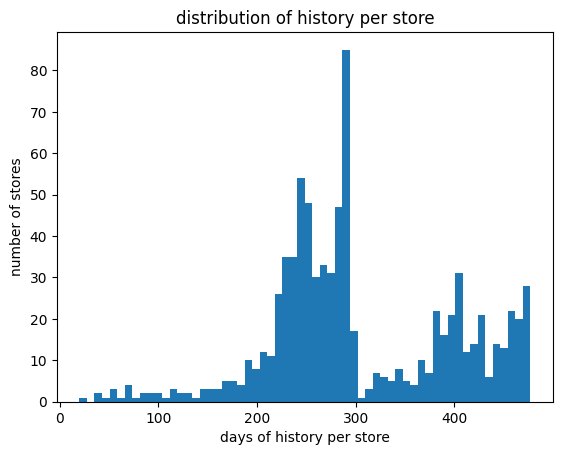

In [0]:
hist_len.plot(kind="hist", bins=60)
plt.xlabel("days of history per store")
plt.ylabel("number of stores")
plt.title("distribution of history per store")
plt.show()

In [0]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


In [0]:
stores.head()

,air_store_id,air_genre_name,air_area_name,latitude,longitude
0,air_0f0cdeee6c9bf3d7,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
1,air_7cc17a324ae5c7dc,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
2,air_fee8dcf4d619598e,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
3,air_a17f0778617c76e2,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
4,air_83db5aff8f50478e,Italian/French,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599


In [0]:
genre_counts = stores["air_genre_name"].value_counts()
genre_counts

air_genre_name
Izakaya                         197
Cafe/Sweets                     181
Dining bar                      108
Italian/French                  102
Bar/Cocktail                     79
Japanese food                    63
Other                            27
Yakiniku/Korean food             23
Western food                     16
Okonomiyaki/Monja/Teppanyaki     14
Creative cuisine                 13
International cuisine             2
Asian                             2
Karaoke/Party                     2
Name: count, dtype: int64

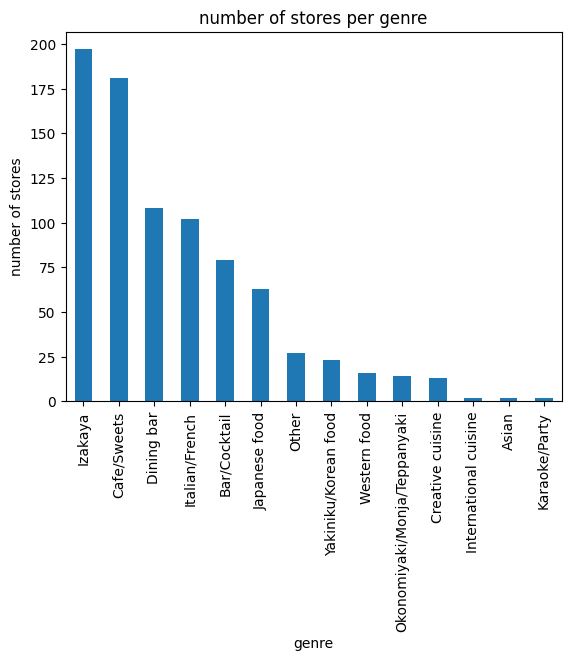

In [0]:
genre_counts.plot(kind="bar")
plt.xlabel("genre")
plt.ylabel("number of stores")
plt.title("number of stores per genre")
plt.show()

In [0]:
stores["air_area_name"].value_counts()

air_area_name
Fukuoka-ken Fukuoka-shi Daimyō           64
Tōkyō-to Shibuya-ku Shibuya              58
Tōkyō-to Minato-ku Shibakōen             51
Tōkyō-to Shinjuku-ku Kabukichō           39
Tōkyō-to Setagaya-ku Setagaya            30
                                         ..
Fukuoka-ken Kitakyūshū-shi Konyamachi     2
Tōkyō-to Taitō-ku Kuramae                 2
Tōkyō-to Shibuya-ku Jingūmae              2
Niigata-ken Kashiwazaki-shi Chūōchō       2
Tōkyō-to Shibuya-ku Higashi               2
Name: count, Length: 103, dtype: int64

In [0]:
stores["air_area_name"].nunique()

103

In [0]:
visits_stores = visits.merge(stores, left_on="air_store_id", right_on="air_store_id", how="left")
visits_stores.head()

,air_store_id,visit_date,visitors,air_genre_name,air_area_name,latitude,longitude
0,air_ba937bf13d40fb24,2016-01-13,25,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599
1,air_ba937bf13d40fb24,2016-01-14,32,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599
2,air_ba937bf13d40fb24,2016-01-15,29,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599
3,air_ba937bf13d40fb24,2016-01-16,22,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599
4,air_ba937bf13d40fb24,2016-01-18,6,Dining bar,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599


In [0]:
visits_stores.groupby("air_genre_name")["visitors"].sum().sort_values(ascending=False)

air_genre_name
Izakaya                         1432337
Cafe/Sweets                     1192802
Italian/French                   677737
Dining bar                       640195
Japanese food                    367352
Bar/Cocktail                     334515
Other                            163781
Yakiniku/Korean food             149182
Western food                     109086
Creative cuisine                  91285
Okonomiyaki/Monja/Teppanyaki      83797
Asian                             20730
Karaoke/Party                     15476
International cuisine              9378
Name: visitors, dtype: int32

In [0]:
visits_stores.groupby("air_area_name")["visitors"].sum().sort_values(ascending=False)

air_area_name
Fukuoka-ken Fukuoka-shi Daimyō           408708
Tōkyō-to Shibuya-ku Shibuya              366744
Tōkyō-to Minato-ku Shibakōen             288180
Tōkyō-to Shinjuku-ku Kabukichō           244996
Tōkyō-to Chūō-ku Tsukiji                 186263
                                          ...  
Ōsaka-fu Neyagawa-shi Honmachi             5424
Fukuoka-ken Kitakyūshū-shi Konyamachi      5254
Tōkyō-to Shibuya-ku Higashi                4133
Hokkaidō Katō-gun Motomachi                3731
Tōkyō-to Setagaya-ku Kitazawa              2166
Name: visitors, Length: 103, dtype: int32

## Conclusions from the EDA

**The data**
- 252,108 visit records across 829 restaurants, running from 2016-01-01 to 2017-04-22 (about 16 months / 477 days).

**Demand is right-skewed**
- Daily visitor counts are heavily right-skewed: lots of quiet days and a long tail of busy ones.
- Taking `log(visitors)` makes the distribution look roughly normal, so it's probably worth modelling on a log scale. The skew also means predicting a *range* (P10–P90) will be more honest than a single number.

**Day of week is the strongest signal**
- Busiest: Saturday (26.3), Sunday (23.9), Friday (23.1). Quietest: Monday (17.2).
- Day-of-week clearly has to be a feature.

**Holidays bump demand up**
- Average visitors on holidays = 23.7 vs 20.8 on normal days (~14% higher), so `holiday_flg` is worth keeping.

**The upward "trend" is misleading**
- Total daily visitors rise over time — but the number of active stores rises in almost the exact same shape (from 48 stores on the first day to ~800 near the end).
- So the growth is mostly new restaurants being onboarded, not existing ones getting busier. Good reason to forecast **per store** rather than on the aggregate total.


**History per store is very uneven**
- Days of history per store: median 284, but ranges from just 20 up to 477.
- The short-history stores are a cold-start problem. This is an argument for a **global model** (one model learning across all stores) instead of a separate model per store.

**Cohorts for later**
- 14 genres and 103 areas. Izakaya (197 stores) and Cafe/Sweets (181) are both the most common genres and the highest in total visitors.
- Genre and area look like sensible groups to compare model performance across in the model-selection step.

**Decisions I'm taking into feature engineering**
1. Forecast per store, not on the aggregate.
2. Lean towards a global model to cope with short-history stores.
3. Core features: day-of-week, holiday flag, and lags / rolling averages of past visitors.
4. Log-transform the target, and produce P10–P90 ranges since demand is so spread out.